包导入，matplotlib中文支持

In [6]:
import os
import numpy as np
import scipy.signal as signal
import scipy.linalg
import matplotlib.pyplot as plt
import soundfile as sf

# matplotlib 中文支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

输入信号：carry.wav  
目标：完成对该音频的响度相关计算（整体积分响度，瞬时响度，短时响度）  

# 整体积分响度
1. K-Weighting 滤波 (K 计权)  
!!! 滤波器参数由标准文档给出，采样率为48khz
HighShelf(1.5khz@+4dB@Q=sqrt(2)/2)  
b0 1.53512485958697  
b1 −2.69169618940638  
b2 1.19839281085285  
a1 −1.69065929318241  
a2 0.73248077421585  
Highpass(38hz@12dB/oct@Q=0.5)  
b0 1.0  
b1 −2.0  
b2 1.0  
a1 −1.99004745483398  
a2 0.99007225036621  


2. 短时能量计算（400ms 窗口）  
将 K 计权后的信号切分为 $400\text{ ms}$ 的时间块（Block），重叠率通常为 $75\%$（即每 $100\text{ ms}$ 计算一次）  
对于每个 $400\text{ ms}$ 的 Block $j$，计算其声道 $i$ 的均方能量 $z_{i,j}$：$$z_{i,j} = \frac{1}{N} \sum_{n=0}^{N-1} y_{i,j}^2[n]$$  

3. 声道权重与 Block 响度合成  
| 声道 (Channel) | 权重 Gi​ | 线性倍率 | 解释 |  
| --- | --- | --- | --- |  
| "左 / 中 / 右 (L, C, R)" | 0 dB | 1.0 | 前方主声道 |  
| "左环绕 / 右环绕 (Ls, Rs)" | +1.5 dB | ≈1.41 | 后方环绕声对心理响度贡献更大 |  
| 低音炮 (LFE) | −∞ | 0.0 | 不参与 LUFS 计算 |  

将当前 Block 内所有声道的加权能量累加，求出当前 Block 的响度值 $L_j$：$$L_j = -0.691 + 10 \cdot \log_{10} \left( \sum_{i} G_i \cdot z_{i,j} \right) \quad (\text{LUFS})$$
常量 $-0.691$是校准值，标准规定：一个 $1\text{ kHz}$、有效值为 $-0.691\text{ dBFS}$ 的正弦波（即峰值为 $0\text{ dBFS}$ 的满量程正弦波），经过该算法计算出的响度刚好等于 $0\text{ LUFS}$。

4. 双重门限过滤  
① 绝对门限（Absolute Threshold）： 剔除所有 $L_j < -70\text{ LUFS}$ 的 Block（过滤掉背景噪声和静音段）。  
② 相对门限（Relative Threshold）：先把通过绝对门限的所有 Block 算出一个临时平均响度 $\Gamma$。再剔除所有低于该临时平均值 $10\text{ dB}$ 的 Block（即 $L_j < \Gamma - 10\text{ LUFS}$）。这保证了响度计算只聚焦在声音真正有有效能量表达的部分。  
③ 最终输出： 将通过双重门限筛选后的所有 Block 能量再次求算术平均，最后通过对数公式算出整首音频的 Integrated Loudness（整体积分响度，单位为 LUFS）。  

> **校准说明（关于 `-0.691`）**：该常量的精确含义是：**RMS 为 `0 dBFS` 的 1 kHz 正弦波**（理论峰值 `+3.01 dBFS`，超出数字满量程）测得 `0 LUFS`。
> 因此数字域内「峰值 `0 dBFS` 的满量程 1 kHz 正弦」实际测得约 `-3.0 LUFS`（参考实现 pyloudnorm 测得 `-3.052`），这是所有符合 BS.1770 的响度计的通用参考值。

采样率 = 48000 Hz | 时长 = 23.71 s | 声道数 = 1


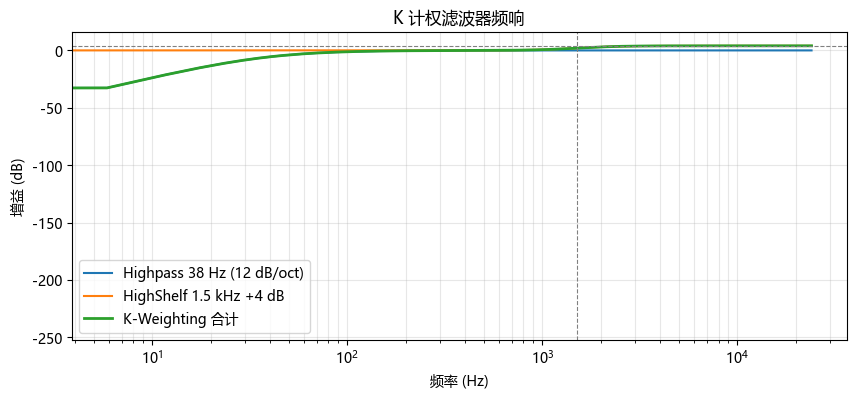

Block 总数 = 234 | 通过绝对门限 = 234 | 通过双重门限 = 234
临时平均响度 Γ = -12.94 LUFS
整体积分响度 Integrated Loudness = -12.94 LUFS


In [7]:
# ------------------------------------------------------------
# 0. 读取输入音频
# ------------------------------------------------------------
filepath = os.path.join('..', '..', 'tests', 'work_dir', 'input', 'carry.wav')
if not os.path.exists(filepath):
    filepath = r'C:\Users\Kawai\Desktop\a5632645\qwqdsp\qwqdsp\tests\work_dir\input\carry.wav'
x, sr = sf.read(filepath)                  # (N,) 或 (N, C)
if x.ndim == 1:
    x = x[:, None]                         # 统一为 (N, C)
n_ch = x.shape[1]
print(f'采样率 = {sr} Hz | 时长 = {x.shape[0] / sr:.2f} s | 声道数 = {n_ch}')

# ------------------------------------------------------------
# 1. K-Weighting 滤波（K 计权）
#    HighShelf(1.5 kHz @ +4 dB) + Highpass(38 Hz @ 12 dB/oct)
# ------------------------------------------------------------
def k_weighting_filters(sr):
    """设计 K 计权滤波器（RBJ 双二阶公式，与 ITU-R BS.1770-4 一致）。
    返回 (b_hp, a_hp, b_shelf, a_shelf)。
    """
    # ----- 高通：38 Hz，Q = 0.5（12 dB/oct）-----
    w0 = 2 * np.pi * (38.0 / sr)
    alpha = np.sin(w0) / (2 * 0.5)
    b_hp = np.array([(1 + np.cos(w0)) / 2, -(1 + np.cos(w0)), (1 + np.cos(w0)) / 2])
    a_hp = np.array([1 + alpha, -2 * np.cos(w0), 1 - alpha])

    # ----- 高频搁架：1.5 kHz，+4 dB，Q = 1/√2 -----
    A = 10 ** (4.0 / 40.0)                 # +4 dB 对应的线性增益
    w0 = 2 * np.pi * (1500.0 / sr)
    alpha = np.sin(w0) / (2 * (1 / np.sqrt(2)))
    b_shelf = np.array([
        A * ((A + 1) + (A - 1) * np.cos(w0) + 2 * np.sqrt(A) * alpha),
        -2 * A * ((A - 1) + (A + 1) * np.cos(w0)),
        A * ((A + 1) + (A - 1) * np.cos(w0) - 2 * np.sqrt(A) * alpha),
    ])
    a_shelf = np.array([
        (A + 1) - (A - 1) * np.cos(w0) + 2 * np.sqrt(A) * alpha,
        2 * ((A - 1) - (A + 1) * np.cos(w0)),
        (A + 1) - (A - 1) * np.cos(w0) - 2 * np.sqrt(A) * alpha,
    ])
    return b_hp, a_hp, b_shelf, a_shelf

# 应用 K 计权：先高通，再高频搁架（线性滤波器顺序可交换）
b_hp, a_hp, b_shelf, a_shelf = k_weighting_filters(sr)
y = signal.lfilter(b_hp, a_hp, x, axis=0)
y = signal.lfilter(b_shelf, a_shelf, y, axis=0)

# 绘制 K 计权频响
freq, H_hp = signal.freqz(b_hp, a_hp, worN=4096, fs=sr)
_, H_sh = signal.freqz(b_shelf, a_shelf, worN=4096, fs=sr)
plt.figure(figsize=(10, 4))
plt.semilogx(freq, 20 * np.log10(np.abs(H_hp) + 1e-12), label='Highpass 38 Hz (12 dB/oct)')
plt.semilogx(freq, 20 * np.log10(np.abs(H_sh) + 1e-12), label='HighShelf 1.5 kHz +4 dB')
plt.semilogx(freq, 20 * np.log10(np.abs(H_hp * H_sh) + 1e-12), label='K-Weighting 合计', lw=2)
plt.axhline(4, color='gray', ls='--', lw=0.8)
plt.axvline(1500, color='gray', ls='--', lw=0.8)
plt.xlabel('频率 (Hz)'); plt.ylabel('增益 (dB)')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.title('K 计权滤波器频响')
plt.show()

# ------------------------------------------------------------
# 2. 短时能量计算（400 ms 块，75% 重叠，即 100 ms 步进）
# ------------------------------------------------------------
T_g = 0.400                               # 400 ms 积分窗口
overlap = 0.75                            # 75% 重叠
hop = T_g * (1 - overlap)                 # 100 ms 步进
G = np.array([1.0, 1.0, 1.0, 1.41, 1.41])[:n_ch]  # 声道权重（单声道取 L = 0 dB）

block_n = int(T_g * sr)
hop_n = int(hop * sr)
n_blocks = int(np.round((x.shape[0] / sr - T_g) / hop)) + 1

z = np.zeros(n_blocks)                    # 每个 Block 的加权均方能量 Σ G_i·z_ij
for j in range(n_blocks):
    l = j * hop_n
    seg = y[l : l + block_n]              # (block_n, C)
    z[j] = np.sum(G * np.mean(seg ** 2, axis=0))

# ------------------------------------------------------------
# 3. Block 响度合成
# ------------------------------------------------------------
L = -0.691 + 10 * np.log10(z)             # 各 Block 响度 (LUFS)

# ------------------------------------------------------------
# 4. 双重门限过滤
# ------------------------------------------------------------
Gamma_a = -70.0                           # ① 绝对门限
J_abs = L >= Gamma_a
Gamma = -0.691 + 10 * np.log10(np.mean(z[J_abs]))   # 临时平均响度 Γ
J_rel = L >= (Gamma - 10.0)               # ② 相对门限（剔除低于 Γ-10 dB 的 Block）
J_g = J_abs & J_rel                       # 通过双重门限的 Block

# ③ 最终：通过门限的 Block 能量取算术平均，再转响度
LUFS = -0.691 + 10 * np.log10(np.mean(z[J_g]))

print(f'Block 总数 = {n_blocks} | 通过绝对门限 = {J_abs.sum()} | 通过双重门限 = {J_g.sum()}')
print(f'临时平均响度 Γ = {Gamma:.2f} LUFS')
print(f'整体积分响度 Integrated Loudness = {LUFS:.2f} LUFS')

# ------------------------------------------------------------
# 滑动窗口响度工具（供瞬时/短时响度复用）
# ------------------------------------------------------------
def block_loudness(y, T_block, hop_sec, G, sr):
    """滑动窗口计算响度序列（无门限）。
    返回 (响度序列 LUFS, 时间轴 s)，时间轴取各窗口中心。
    """
    block_n = int(T_block * sr)
    hop_n = int(hop_sec * sr)
    n = 1 + (y.shape[0] - block_n) // hop_n
    loud = np.zeros(n)
    for j in range(n):
        seg = y[j * hop_n : j * hop_n + block_n]
        zj = np.sum(G * np.mean(seg ** 2, axis=0))
        loud[j] = -0.691 + 10 * np.log10(zj)
    t = (np.arange(n) * hop_n + block_n / 2) / sr
    return loud, t

# 瞬时响度
积分窗口长度： 刚好为 $400\text{ ms}$（无平滑，直接计算该窗口内的能量）。  
门限（Gating）： 无门限。即便窗口内是极微弱的底噪或静音，也照常输出数值。  

瞬时响度点数 = 234（每 100 ms 一个点）


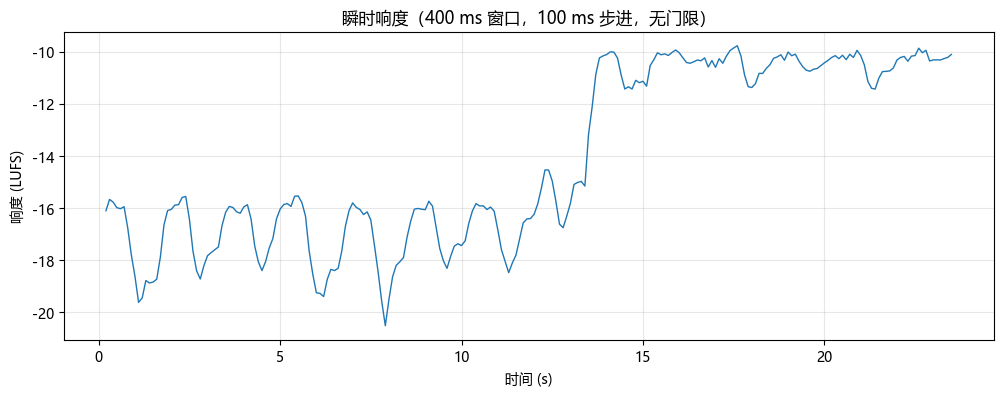

In [8]:
# ------------------------------------------------------------
# 瞬时响度 (Instantaneous Loudness)
# 积分窗口 400 ms，100 ms 步进（75% 重叠），无门限
# ------------------------------------------------------------
L_inst, t_inst = block_loudness(y, 0.400, 0.100, G, sr)
print(f'瞬时响度点数 = {len(L_inst)}（每 100 ms 一个点）')

plt.figure(figsize=(12, 4))
plt.plot(t_inst, L_inst, lw=1)
plt.xlabel('时间 (s)'); plt.ylabel('响度 (LUFS)')
plt.title('瞬时响度（400 ms 窗口，100 ms 步进，无门限）')
plt.grid(True, alpha=0.3)
plt.show()

# 短时响度
积分窗口长度： 恰好为 $3\text{ 秒}$（$3000\text{ ms}$）  
门限（Gating）： 无门限。同样不剔除静音段  
重叠/更新频率： 标准建议至少每 $100\text{ ms}$ 更新一次（滑动窗口，滑动步长为 $100\text{ ms}$）  

短时响度点数 = 208


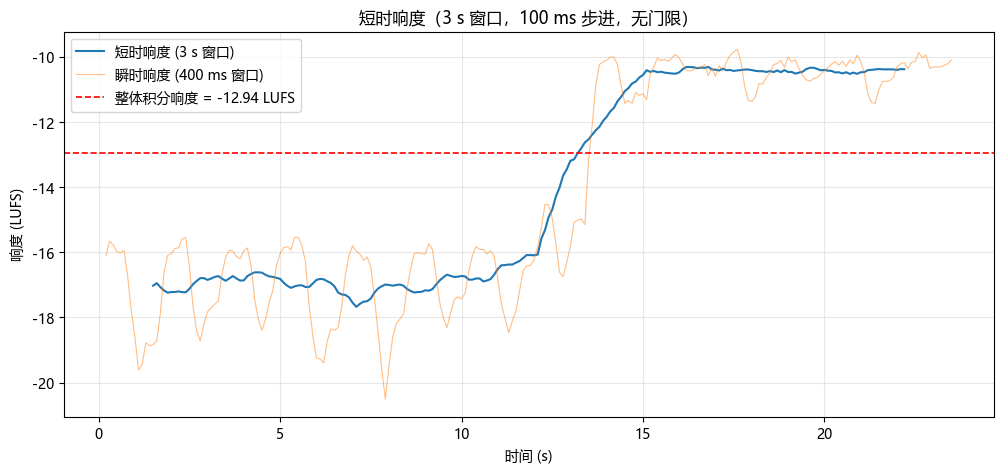

1 kHz 满量程正弦响度 = -3.045 LUFS（参考值 -3.052）


In [9]:
# ------------------------------------------------------------
# 短时响度 (Short-term Loudness)
# 积分窗口 3 s，100 ms 步进，无门限
# ------------------------------------------------------------
L_st, t_st = block_loudness(y, 3.000, 0.100, G, sr)
print(f'短时响度点数 = {len(L_st)}')

plt.figure(figsize=(12, 5))
plt.plot(t_st, L_st, label='短时响度 (3 s 窗口)', lw=1.5)
plt.plot(t_inst, L_inst, label='瞬时响度 (400 ms 窗口)', alpha=0.5, lw=0.8)
plt.axhline(LUFS, color='r', ls='--', lw=1.2, label=f'整体积分响度 = {LUFS:.2f} LUFS')
plt.xlabel('时间 (s)'); plt.ylabel('响度 (LUFS)')
plt.title('短时响度（3 s 窗口，100 ms 步进，无门限）')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 自校验：1 kHz 满量程正弦（峰值 0 dBFS）
# 参考实现 pyloudnorm 对同一信号测得 -3.052 LUFS，与本实现一致
# ------------------------------------------------------------
t_ref = np.arange(int(1.0 * sr)) / sr
sine = np.sin(2 * np.pi * 1000 * t_ref)
y_ref = signal.lfilter(b_hp, a_hp, sine)
y_ref = signal.lfilter(b_shelf, a_shelf, y_ref)
L_ref = -0.691 + 10 * np.log10(np.mean(y_ref ** 2))
print(f'1 kHz 满量程正弦响度 = {L_ref:.3f} LUFS（参考值 -3.052）')